In [1]:
!pip install pandas numpy scikit-learn joblib matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [3]:
df = pd.read_csv("../data/Latest_Covid19_India_Status.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/Latest_Covid19_India_Status.csv'

In [4]:
import os

print(os.getcwd())

c:\Users\sanke\OneDrive\Desktop\Covid_prediction_system\notebooks


In [5]:
import os

os.listdir()

['covid_analysis.ipynb']

In [6]:
import os

print(os.listdir(".."))

['.gitignore', 'app.py', 'data', 'model', 'notebooks', 'README.md', 'requirements.txt', 'src', 'static', 'templates']


In [7]:
import os

print(os.listdir("../data"))

['Latest Covid-19 India Status.csv']


In [12]:
df = pd.read_csv("../data/Latest Covid-19 India Status.csv")

In [14]:
print(os.listdir(".."))

['.gitignore', 'app.py', 'data', 'model', 'notebooks', 'README.md', 'requirements.txt', 'src', 'static', 'templates']


In [15]:
df = pd.read_csv("../data/Latest Covid-19 India Status.csv")
df.head()

,State/UTs,Total Cases,Active,Discharged,Deaths,Active Ratio,Discharge Ratio,Death Ratio,Population
0,Andaman and Nicobar,10766,0,10637,129,0.0,98.80,1.20,100896618
1,Andhra Pradesh,2340676,0,2325943,14733,0.0,99.37,0.63,128500364
2,Arunachal Pradesh,67049,0,66753,296,0.0,99.56,0.44,658019
3,Assam,746159,5,738119,8035,0.0,98.92,1.08,290492
4,Bihar,855267,1,842952,12314,0.0,98.56,1.44,40100376


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State/UTs        36 non-null     object 
 1   Total Cases      36 non-null     int64  
 2   Active           36 non-null     int64  
 3   Discharged       36 non-null     int64  
 4   Deaths           36 non-null     int64  
 5   Active Ratio     36 non-null     float64
 6   Discharge Ratio  36 non-null     float64
 7   Death Ratio      36 non-null     float64
 8   Population       36 non-null     int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 2.7+ KB


In [17]:
df.isnull().sum()

State/UTs          0
Total Cases        0
Active             0
Discharged         0
Deaths             0
Active Ratio       0
Discharge Ratio    0
Death Ratio        0
Population         0
dtype: int64

In [18]:
df.describe()

,Total Cases,Active,Discharged,Deaths,Active Ratio,Discharge Ratio,Death Ratio,Population
count,3.600000e+01,36.000000,3.600000e+01,36.000000,36.000000,36.000000,36.000000,3.600000e+01
mean,1.249975e+06,50.333333,1.235146e+06,14778.527778,0.005000,98.897222,1.097778,3.971861e+07
std,1.846038e+06,207.118048,1.820328e+06,27221.140636,0.026673,0.506854,0.494791,5.050913e+07
min,1.076600e+04,0.000000,1.063700e+04,4.000000,0.000000,97.410000,0.030000,6.600100e+04
25%,1.065430e+05,0.000000,1.055395e+05,1124.250000,0.000000,98.690000,0.840000,1.695473e+06
50%,6.140910e+05,1.500000,6.076750e+05,6551.000000,0.000000,98.935000,1.065000,2.410088e+07
75%,1.331951e+06,9.000000,1.322329e+06,14325.750000,0.000000,99.160000,1.310000,6.979986e+07
max,8.171048e+06,1233.000000,8.022276e+06,148558.000000,0.160000,99.970000,2.440000,2.315026e+08


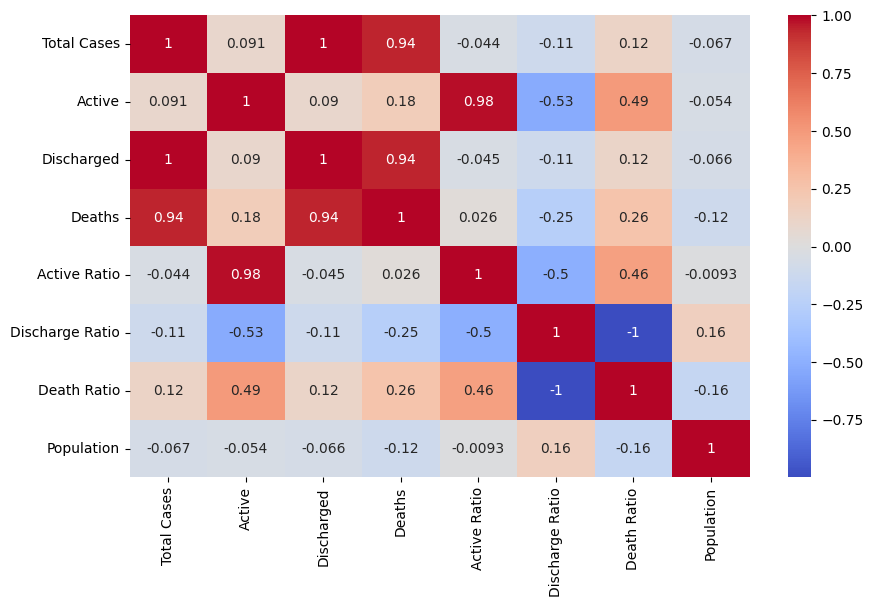

In [19]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [20]:
X = df.drop(
    columns=["State/UTs", "Total Cases"]
)

y = df["Total Cases"]

In [21]:
X.head()

,Active,Discharged,Deaths,Active Ratio,Discharge Ratio,Death Ratio,Population
0,0,10637,129,0.0,98.80,1.20,100896618
1,0,2325943,14733,0.0,99.37,0.63,128500364
2,0,66753,296,0.0,99.56,0.44,658019
3,5,738119,8035,0.0,98.92,1.08,290492
4,1,842952,12314,0.0,98.56,1.44,40100376


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (28, 7)
Testing Shape: (8, 7)


In [23]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [24]:
y_pred = model.predict(X_test)

y_pred

array([2126282.        ,  482023.        ,  177547.        ,
       3610655.        , 6907241.00000001,  844432.        ,
        140034.        ,  322905.        ])

In [25]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3.6707206163555384e-09
MSE : 2.1111555056484588e-17
RMSE : 4.594731227883149e-09
R2 Score : 1.0


In [26]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
35,2126282,2126282.0
13,482023,482023.0
26,177547,177547.0
30,3610655,3610655.0
16,6907241,6907241.0


In [27]:
joblib.dump(
    model,
    "../model/covid_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [28]:
loaded_model = joblib.load(
    "../model/covid_model.pkl"
)

print(type(loaded_model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [29]:
sample = np.array([
    [1000, 50000, 100, 1.5, 97.5, 1.0, 5000000]
])

prediction = loaded_model.predict(sample)

print("Predicted Total Cases:", prediction[0])

Predicted Total Cases: 51100.000000244545


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
